# 25. Live Tutorial 4: Optimization and Mixture Designs

A reduced model isn't the end of a DoE study — it's a map. This session
picks up right where Notebook 24 left off (a trustworthy reduced model of
the adhesive-bonding process) and asks: **which direction do you move
in next?** Then it turns to a design type every previous DoE notebook has
sidestepped: **mixture designs**, for the very common materials-science
situation where your "factors" are ingredient proportions that must sum to
100% — a constraint standard factorial designs simply cannot represent.

**Session plan**
1. A short bridge: from a reduced model to an optimum
2. Mixture designs — the constraint standard DoE ignores
3. Simplex-lattice and simplex-centroid designs, built by hand
4. Fitting a Scheffé mixture model
5. Reading a ternary contour plot

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product, combinations
import statsmodels.formula.api as smf
from scipy import stats

sns.set_theme(style='ticks', palette='colorblind')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
rng = np.random.default_rng(303)

## 25.1 A Short Bridge: From a Reduced Model to an Optimum

Notebooks 19–20 already cover steepest ascent and desirability
optimization in depth — this is a short bridge, not a repeat. **Steepest
ascent** moves you toward better settings by following the model's
**slopes**: move each factor in proportion to how much the response rises
per unit of that factor.

Notebook 24's reduced model has five main effects **and two interactions**
(A:B and C:D). Do the interactions change the direction — and where should
the path start? A two-factor toy example first.

### Toy example: an interaction tilts the uphill direction

Take $y = 10 + 3A + 4B + 2AB$: main-effect slopes 3 and 4 (a 3-4-5
triangle, so the direction is (0.6, 0.8)), plus one interaction. The slope in A is how much $y$ rises per unit of A with B
held fixed; the term $2AB$ rises by $2B$ per unit of A, so

$$\text{slope in A} = 3 + 2B, \qquad \text{slope in B} = 4 + 2A .$$

| Point (A, B) | Slope in A | Slope in B | Uphill direction |
|---|---|---|---|
| centre (0, 0) | 3 | 4 | (0.60, 0.80) |
| (0.6, 0.8) | 4.6 | 5.2 | (0.66, 0.75) |
| best corner (1, 1) | 5 | 6 | (0.64, 0.77) |

At the centre, A = B = 0, so the interaction adds **no slope**: uphill is
given by the main effects alone. Anywhere else, the interaction tilts it —
the uphill arrows are **not parallel**. That raises a practical question:
the classic recipe (Box & Wilson) starts the path at the centre, but its
first steps only re-visit
the box that has already been tested. Why not start at the **best corner
of the box**, with the slope *there*? The next cell compares both.

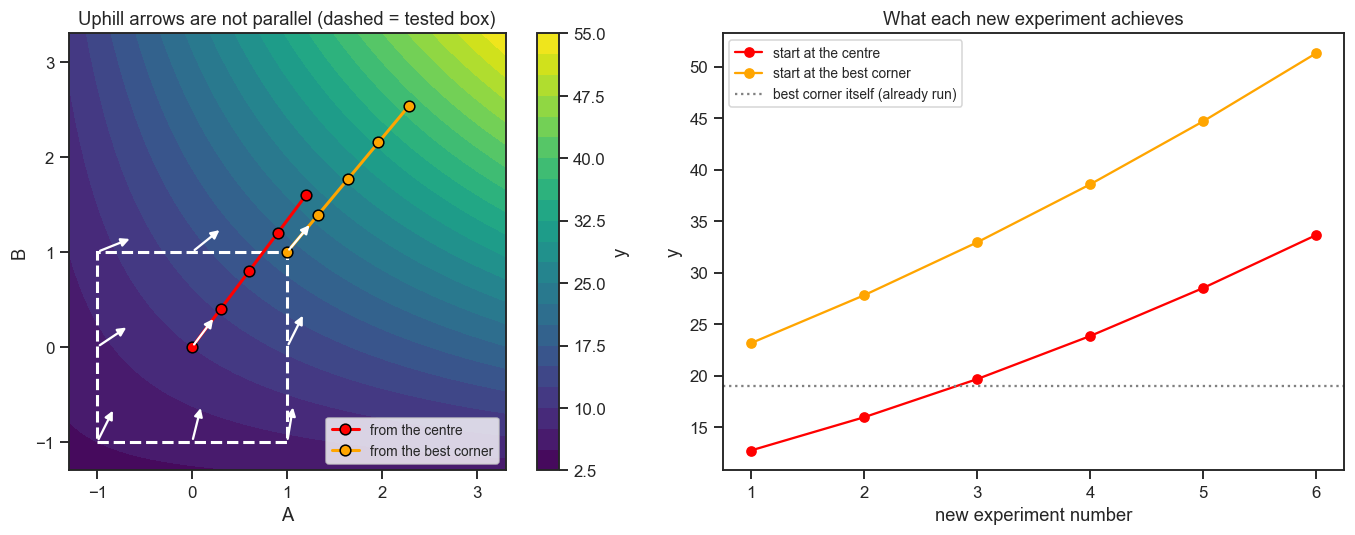

In [2]:
def toy(A, B):
    return 10 + 3*A + 4*B + 2*A*B                        # toy model with one interaction

def toy_slope(A, B):
    return np.array([3 + 2*B, 4 + 2*A])                  # slope in A, slope in B

g = np.linspace(-1.3, 3.3, 141)
AA, BB = np.meshgrid(g, g)
k = np.arange(1, 7)                                      # new experiments 1..6
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
cs = ax.contourf(AA, BB, toy(AA, BB), levels=20, cmap='viridis')
plt.colorbar(cs, ax=ax, label='y')
ax.add_patch(plt.Rectangle((-1, -1), 2, 2, fill=False, edgecolor='white', lw=2, ls='--'))   # the tested box
for a in (-1, 0, 1):
    for b_ in (-1, 0, 1):
        s = toy_slope(a, b_)
        u = 0.4 * s / np.linalg.norm(s)                  # a short arrow pointing uphill from (a, b_)
        ax.annotate('', xy=(a + u[0], b_ + u[1]), xytext=(a, b_),
                    arrowprops=dict(arrowstyle='-|>', color='white', lw=1.5))
for name, st, colour in [('the centre', np.array([0.0, 0.0]), 'red'),
                         ('the best corner', np.array([1.0, 1.0]), 'orange')]:
    u = toy_slope(*st) / np.linalg.norm(toy_slope(*st))  # local uphill direction at the start
    pts = np.array([st + u * 0.5 * i for i in range(5)])
    ax.plot(pts[:, 0], pts[:, 1], 'o-', color=colour, mec='black', ms=7, lw=2, label=f'from {name}')
    axes[1].plot(k, [toy(*(st + u * 0.5 * i)) for i in k], 'o-', color=colour, label=f'start at {name}')
ax.set(xlabel='A', ylabel='B', title='Uphill arrows are not parallel (dashed = tested box)')
ax.set_aspect('equal'); ax.legend(loc='lower right', fontsize=9)
axes[1].axhline(toy(1, 1), color='gray', ls=':', label='best corner itself (already run)')
axes[1].set(xlabel='new experiment number', ylabel='y', title='What each new experiment achieves')
axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

From the centre, the first 3 new experiments only climb back to the level
of the corner that was already run (y = 19); from the corner, every new
experiment is new ground, and its direction already includes the
interaction's tilt. The rule of thumb:

- **No important interactions** → start at the **centre**: the arrows are
  parallel, so the start does not change the direction, and the slope is
  estimated most precisely there.
- **Important interactions** → start at the **model's best corner** of the
  tested box, with the local slope there. Use the model's prediction to
  pick the corner, not the best *measured* run: the best of many noisy runs
  is partly luck.

Notebook 24's adhesive model has strong interactions (A:B and C:D, both
p < 0.001), so that is where its path starts. The cell below briefly
regenerates that reduced model from scratch (same seed, same design, same
true model) — see Notebook 24 for the full backward-elimination
walkthrough.

In [3]:
# ── Quick setup: regenerate Notebook 24 (Live Tutorial 3) §24.2's reduced model ──
import pyDOE3

design_gen = pyDOE3.fracfact('a b c d abcd')     # 2^(5-1), Resolution V, I=ABCDE
df_adh = pd.DataFrame(design_gen, columns=['A', 'B', 'C', 'D', 'E'])

def true_adhesive_strength(df):
    return (18
            + 4*df.A + 6*df.B + 3*df.C - 2*df.D - 1*df.E
            + 2*df.A*df.B - 1.5*df.C*df.D + 0*df.B*df.C + 0*df.A*df.E)

df_adh['strength_MPa'] = (true_adhesive_strength(df_adh) + rng.normal(0, 1.0, len(df_adh))).round(2)

def backward_elimination(data, response, candidate_terms, alpha=0.05, verbose=False):
    terms = list(candidate_terms)
    while True:
        formula = f'{response} ~ ' + ' + '.join(terms)
        fit = smf.ols(formula, data=data).fit()
        pvalues = fit.pvalues.drop('Intercept')
        worst_term, worst_p = pvalues.idxmax(), pvalues.max()
        if worst_p <= alpha or len(terms) == 1:
            return fit, terms
        terms.remove(worst_term)


candidates = ['A', 'B', 'C', 'D', 'E', 'A:B', 'C:D', 'B:C', 'A:E']
model_reduced, kept_terms = backward_elimination(df_adh, 'strength_MPa', candidates)
print('Reduced model terms:', kept_terms)

Reduced model terms: ['A', 'B', 'C', 'D', 'E', 'A:B', 'C:D']


In [4]:
# Steepest ascent follows the model's slopes. With strong interactions the slopes differ
# across the box, so the path starts at the MODEL's best corner, along the local slope there
def local_slope(row):
    # The reduced model's slope in each factor at a point (interactions included)
    p = model_reduced.params
    return np.array([p['A'] + p['A:B'] * row.B, p['B'] + p['A:B'] * row.A,
                     p['C'] + p['C:D'] * row.D, p['D'] + p['C:D'] * row.C, p['E']])

corners = pd.DataFrame(list(product([-1, 1], repeat=5)), columns=list('ABCDE'))   # all 32 corners of the box
start = corners.loc[model_reduced.predict(corners).idxmax()]                      # the model's best corner
in_design = (df_adh[list('ABCDE')].values == start.values).all(axis=1).any()
print("Start = the model's best corner:", start.to_dict(), '- already one of the 16 runs:', in_design, '\n')

slopes = pd.DataFrame({'at the centre': local_slope(pd.Series(0.0, index=list('ABCDE'))),
                       'at the start corner': local_slope(start)}, index=list('ABCDE'))
print('Local slopes (MPa per coded unit):')
print(slopes.round(2))

direction_normalized = slopes['at the start corner'] / np.linalg.norm(slopes['at the start corner'])
step_size = 0.5   # coded units per step
path = pd.DataFrame([start.values + direction_normalized.values * step_size * i for i in range(6)],
                    columns=list('ABCDE'))
path.index.name = 'step'
print('\nThe steepest-ascent path (coded units; step 0 = the corner, already run):')
print(path.round(2))
print('\nRun these one at a time and stop when the response stops improving; then fit a new small')
print("factorial around the best point and re-aim -- exactly Notebook 20's workflow -- until curvature")
print("appears (Notebook 22, Live Tutorial 1, Section 22.4's test) and it is time for a full RSM model (Notebook 19).")

Start = the model's best corner: {'A': 1, 'B': 1, 'C': 1, 'D': -1, 'E': -1} - already one of the 16 runs: True 

Local slopes (MPa per coded unit):
   at the centre  at the start corner
A           4.19                 6.28
B           6.18                 8.26
C           2.98                 4.80
D          -1.59                -3.42
E          -1.11                -1.11

The steepest-ascent path (coded units; step 0 = the corner, already run):
         A     B    C     D     E
step                             
0     1.00  1.00  1.0 -1.00 -1.00
1     1.26  1.34  1.2 -1.14 -1.05
2     1.52  1.69  1.4 -1.28 -1.09
3     1.79  2.03  1.6 -1.43 -1.14
4     2.05  2.38  1.8 -1.57 -1.18
5     2.31  2.72  2.0 -1.71 -1.23

Run these one at a time and stop when the response stops improving; then fit a new small
factorial around the best point and re-aim -- exactly Notebook 20's workflow -- until curvature
appears (Notebook 22, Live Tutorial 1, Section 22.4's test) and it is time for a full RSM m

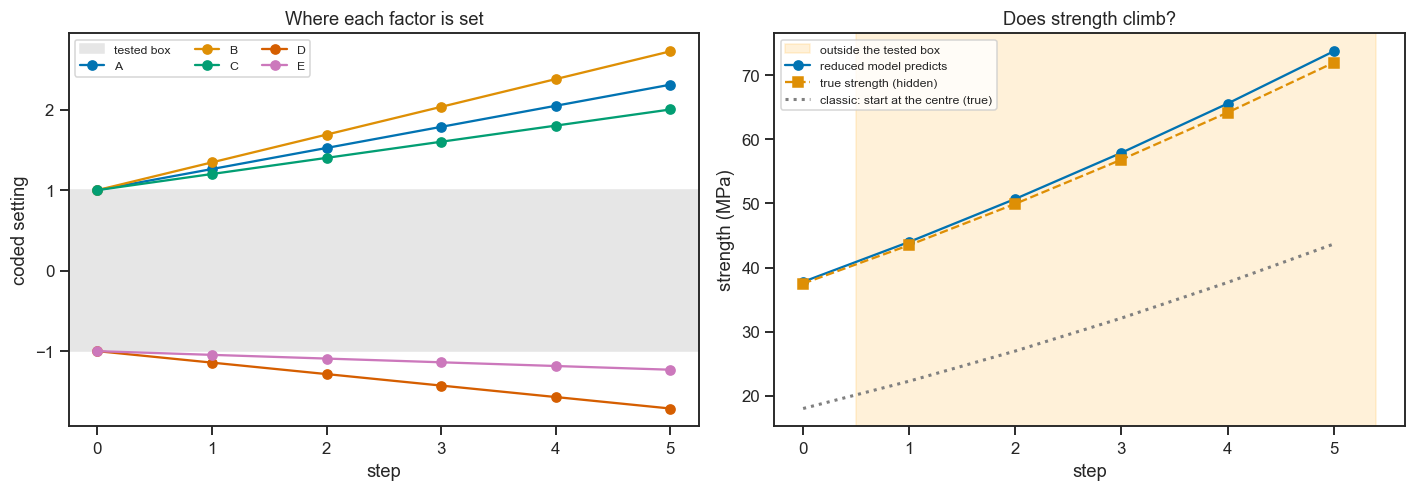

True strength, start at the best corner: [37.5 43.5 49.9 56.8 64.2 72. ]
True strength, start at the centre:      [18.  22.3 27.  32.1 37.7 43.7]


In [5]:
# The path, drawn: where each factor is set, and what the strength does -- with the
# classic path from the centre (Box & Wilson) for comparison
centre_dir = slopes['at the centre'] / np.linalg.norm(slopes['at the centre'])
centre_path = pd.DataFrame([centre_dir.values * step_size * i for i in range(6)], columns=list('ABCDE'))
steps = path.index.values

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ax = axes[0]
ax.axhspan(-1, 1, color='0.9', label='tested box')
for f in path.columns:
    ax.plot(steps, path[f], 'o-', label=f)
ax.set(xlabel='step', ylabel='coded setting', title='Where each factor is set')
ax.legend(fontsize=8, ncol=3, loc='upper left')

ax = axes[1]
ax.axvspan(0.5, steps[-1] + 0.4, color='orange', alpha=0.15, label='outside the tested box')
ax.plot(steps, model_reduced.predict(path), 'o-', label='reduced model predicts')
ax.plot(steps, true_adhesive_strength(path), 's--', label='true strength (hidden)')
ax.plot(steps, true_adhesive_strength(centre_path), ':', color='gray', lw=2,
        label='classic: start at the centre (true)')
ax.set(xlabel='step', ylabel='strength (MPa)', title='Does strength climb?')
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout(); plt.show()

print('True strength, start at the best corner:', true_adhesive_strength(path).round(1).values)
print('True strength, start at the centre:     ', true_adhesive_strength(centre_path).round(1).values)

**Checkpoint**: compute the slopes at the start corner (+1, +1, +1, −1, −1)
by hand from the reduced model's coefficients (A 4.19, B 6.18, C 2.98,
D −1.59, E −1.11, A:B 2.09, C:D −1.82), as in the toy table. Which
factor's slope changes most compared with the centre, and why? And how
many steps of the classic centre path would you spend before reaching the
strength the corner path starts with?

:::{admonition} Take-home message
:class: tip

- Steepest ascent follows the model's **slopes**. At the centre an
  interaction adds no slope, so the direction there is the main effects;
  anywhere else it tilts the direction. At the adhesive model's best corner
  the slope in D more than doubles (−1.59 → −3.42), because C is high:
  through C:D, a thinner bondline helps more at high clamp pressure.
- **Where to start**: at the centre if interactions are small; at the
  **model's** best corner, with its local slope, if they matter — as here.
  That corner is one of the 16 runs already made, so starting there is not
  an extrapolation. The classic centre path would spend its first 3 steps
  re-visiting the tested box and reach the corner's 37.5 MPa only at
  step 4.
- Each step is a real experiment: stop when the response stops improving,
  then re-aim from a new small factorial. This simulated process has no
  curvature, so the climb never ends here — Exercise 5 adds a process
  limit and asks when to switch to RSM.
:::

## 25.2 Mixture Designs: The Constraint Standard DoE Ignores

Every design so far — factorial, fractional, RSM — assumed factors can be
set **independently**: cranking up temperature does not force pressure to
change. Formulation problems break that assumption completely. Blend three
solvents for a battery electrolyte and their volume fractions **must sum
to 100%** — increase one, and at least one other necessarily decreases.
Run a standard $2^3$ factorial on volume fractions and at most 3 of its 8
corners describe a real mixture: with low and high levels of 0.2 and 0.6,
for example, only the three corners with one component high and two low
sum to 1 — the others sum to 0.6, 1.4 or 1.8.

The feasible region for $q$ components is not a cube — it's the
**simplex**: for 3 components, a triangle; for 4, a tetrahedron. A
**mixture design** places runs *within* that constrained region instead of
a cube's corners.

## 25.3 Simplex-Lattice and Simplex-Centroid Designs, Built by Hand

A $\{q,m\}$ **simplex-lattice design** takes every combination of $q$
components at $m{+}1$ evenly spaced levels ($0, 1/m, 2/m, \ldots, 1$) whose
proportions sum to exactly 1. For $q=3,\ m=2$: levels $\{0, 0.5, 1\}$,
giving the 3 pure-component vertices plus the 3 binary-blend edge
midpoints — 6 points total, and every one of them a physically realisable
blend by construction.

A **simplex-centroid design** takes a different route: **one point for
every non-empty subset** of the $q$ components, blended in **equal**
proportions — the pure components (subsets of 1), the 50/50 binary blends
(subsets of 2), the 1/3–1/3–1/3 blend (subsets of 3), and so on: $2^q - 1$
points. For $q = 3$: the same 6 points as the {3, 2} lattice **plus the
overall centroid** (1/3, 1/3, 1/3) — 7 points.

That one extra point matters:

- The {3, 2} lattice has **no interior point**: every run is on an edge, so
  no run ever contains all three components. The centroid is that blend.
- The lattice's 6 points exactly match the 6 parameters of the quadratic
  mixture model (25.4): a perfect fit with no degrees of freedom left. The
  centroid — replicated — gives the degrees of freedom to test the model.
- Only a design with the centroid can fit the **special cubic** term
  $x_1 x_2 x_3$ (Exercise 3).

The design used in 25.4 is exactly the simplex-centroid design, with its
centroid run three times.

{3, 2} simplex-lattice design (6 points):
    EC  EMC  DMC
0  0.0  0.0  1.0
1  0.0  0.5  0.5
2  0.0  1.0  0.0
3  0.5  0.0  0.5
4  0.5  0.5  0.0
5  1.0  0.0  0.0

Simplex-centroid design (7 points): the same 6 points plus the overall centroid [0.333 0.333 0.333]


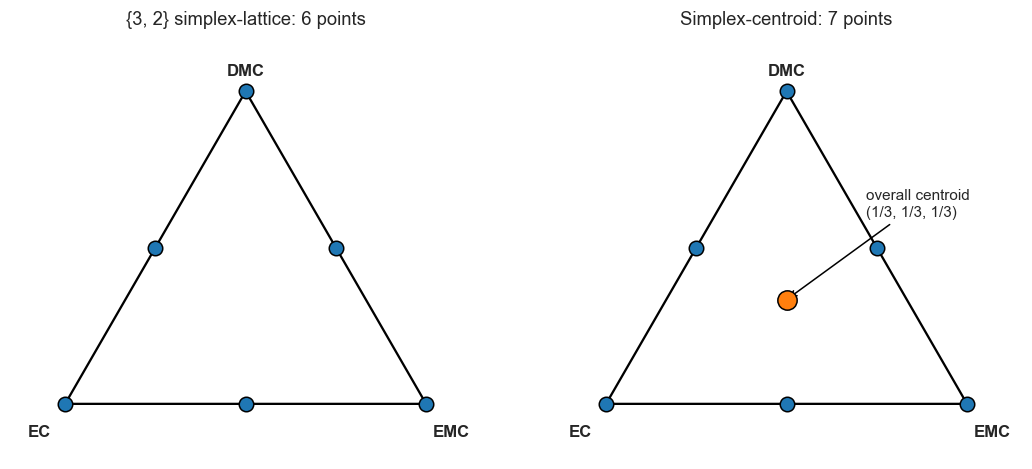

In [6]:
def simplex_lattice(q, m):
    """All q-component blends at levels {0, 1/m, ..., 1} that sum to 1."""
    levels = [i / m for i in range(m + 1)]
    return np.array([combo for combo in product(levels, repeat=q) if np.isclose(sum(combo), 1.0)])

def simplex_centroid(q):
    """The centroid of every non-empty subset of q components (2^q - 1 points)."""
    points = []
    for r in range(1, q + 1):
        for subset in combinations(range(q), r):
            point = np.zeros(q)
            point[list(subset)] = 1.0 / r
            points.append(point)
    return np.array(points)


lattice_32 = simplex_lattice(q=3, m=2)
centroid_3 = simplex_centroid(q=3)
print(f'{{3, 2}} simplex-lattice design ({len(lattice_32)} points):')
print(pd.DataFrame(lattice_32, columns=['EC', 'EMC', 'DMC']))
print(f'\nSimplex-centroid design ({len(centroid_3)} points): the same 6 points plus the overall centroid',
      centroid_3[-1].round(3))

# Both designs on the triangle: corners = pure components (EC bottom left, EMC bottom right, DMC top)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))
for ax, (title, pts) in zip(axes, [('{3, 2} simplex-lattice: 6 points', lattice_32),
                                   ('Simplex-centroid: 7 points', centroid_3)]):
    ax.add_patch(plt.Polygon([(0, 0), (1, 0), (0.5, np.sqrt(3) / 2)], fill=False, edgecolor='black', lw=1.5))
    x, y = pts[:, 1] + 0.5 * pts[:, 2], (np.sqrt(3) / 2) * pts[:, 2]      # blend -> position in the triangle
    ax.scatter(x, y, s=90, color='tab:blue', edgecolor='black', zorder=3)
    for label, (vx, vy) in zip(['EC', 'EMC', 'DMC'], [(-0.07, -0.09), (1.07, -0.09), (0.5, 0.91)]):
        ax.text(vx, vy, label, ha='center', fontweight='bold')
    ax.set_title(title, pad=12); ax.set_xlim(-0.15, 1.15); ax.set_ylim(-0.15, 1.0)
    ax.set_aspect('equal'); ax.axis('off')
axes[1].scatter([0.5], [np.sqrt(3) / 6], s=160, color='tab:orange', edgecolor='black', zorder=4)
axes[1].annotate('overall centroid\n(1/3, 1/3, 1/3)', xy=(0.5, np.sqrt(3) / 6), xytext=(0.72, 0.52),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)
plt.tight_layout(); plt.show()

## 25.4 Fitting a Scheffé Mixture Model

**Electrolyte solvent blend study**: three carbonate solvents — **EC**
(ethylene carbonate), **EMC** (ethyl methyl carbonate), **DMC** (dimethyl
carbonate) — blended in varying proportions, response = ionic conductivity
(mS/cm). We use the 6-point $\{3,2\}$ lattice plus the overall centroid,
**replicated 3 times** — 9 runs (the mixture-design equivalent of Notebook 22 (Live
Tutorial 1) §22.4's centre-point replication, for a pure-error / lack-of-fit
check), and fit a **Scheffé quadratic model**:

$$y = \sum_i \beta_i x_i + \sum_{i<j} \beta_{ij}\, x_i x_j$$

Notice there is **no intercept term**. Because $x_1+x_2+x_3=1$ always,
an intercept would be perfectly collinear with the three linear terms —
the regression matrix would be singular. Dropping the intercept
(`-1` in the formula) is not a stylistic choice here; it is required for
the model to be fittable at all, and is the single most important
scripting detail that differs from every other regression in this
course.

In [7]:
mixture_points = np.vstack([lattice_32, np.tile([1/3, 1/3, 1/3], (3, 1))])   # + 3 centroid replicates
df_mix = pd.DataFrame(mixture_points, columns=['EC', 'EMC', 'DMC'])

# True Scheffe model: pure-component conductivities + interaction (blending) terms.
# Positive interaction terms model the real, well-documented phenomenon that binary
# carbonate-solvent blends often conduct better than a linear blend of the pure
# components would predict (a genuine synergy, not just illustrative convenience).
b = {'EC': 3.0, 'EMC': 5.5, 'DMC': 6.0, 'EC:EMC': 4.0, 'EC:DMC': 3.0, 'EMC:DMC': -1.0}
true_cond = (b['EC']*df_mix.EC + b['EMC']*df_mix.EMC + b['DMC']*df_mix.DMC
             + b['EC:EMC']*df_mix.EC*df_mix.EMC + b['EC:DMC']*df_mix.EC*df_mix.DMC
             + b['EMC:DMC']*df_mix.EMC*df_mix.DMC)
df_mix['conductivity_mS_cm'] = (true_cond + rng.normal(0, 0.15, len(df_mix))).round(3)
print(df_mix)

         EC       EMC       DMC  conductivity_mS_cm
0  0.000000  0.000000  1.000000               5.534
1  0.000000  0.500000  0.500000               5.596
2  0.000000  1.000000  0.000000               5.596
3  0.500000  0.000000  0.500000               5.242
4  0.500000  0.500000  0.000000               5.251
5  1.000000  0.000000  0.000000               3.177
6  0.333333  0.333333  0.333333               5.255
7  0.333333  0.333333  0.333333               5.496
8  0.333333  0.333333  0.333333               5.775


In [8]:
model_mix = smf.ols('conductivity_mS_cm ~ EC + EMC + DMC '
                     '+ EC:EMC + EC:DMC + EMC:DMC - 1', data=df_mix).fit()
print(model_mix.summary().tables[1])

# Lack-of-fit test, same F-test logic as Notebook 22 (Live Tutorial 1) §22.4:
# 3 residual df = 2 df pure error (the centroid replicates) + 1 df lack of fit
centroid_reps = df_mix['conductivity_mS_cm'].iloc[-3:]
ss_resid = (model_mix.resid ** 2).sum()
ss_pe = ((centroid_reps - centroid_reps.mean()) ** 2).sum()     # scatter between true replicates
ss_lof = ss_resid - ss_pe                                        # what the model misses beyond noise
F = (ss_lof / 1) / (ss_pe / 2)
print(f'\nCentroid replicates: {centroid_reps.values}')
print(f'Pure-error SD at the centroid: {np.sqrt(ss_pe / 2):.3f} mS/cm   (true noise SD = 0.15)')
print(f'Lack-of-fit test: F = {F:.2f}, p = {stats.f.sf(F, 1, 2):.3f}')

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
EC             3.1830      0.213     14.922      0.001       2.504       3.862
EMC            5.6020      0.213     26.262      0.000       4.923       6.281
DMC            5.5400      0.213     25.971      0.000       4.861       6.219
EC:EMC         3.3372      0.933      3.578      0.037       0.369       6.305
EC:DMC         3.4252      0.933      3.672      0.035       0.457       6.393
EMC:DMC        0.0032      0.933      0.003      0.997      -2.965       2.971

Centroid replicates: [5.255 5.496 5.775]
Pure-error SD at the centroid: 0.260 mS/cm   (true noise SD = 0.15)
Lack-of-fit test: F = 0.04, p = 0.857


:::{admonition} Take-home message
:class: tip

- Each linear coefficient is essentially the single measurement at its
  vertex: at a pure component every blending term is zero, and there is
  only one run there. EC (3.18, true 3.0) and EMC (5.60, true 5.5) land
  close; **DMC comes out at 5.54 against a true 6.0**, because the one DMC
  run happened to come out 0.47 low — about 3σ, an unlucky but possible
  draw. The model's *shape* is fine (lack-of-fit p = 0.86); one
  unreplicated vertex is the weak spot.
- The blending coefficients are about 4× less precise than the linear ones
  (standard error 0.93 against 0.21): each is estimated from a *difference*
  between a midpoint run and two vertex runs, so it collects the noise of
  several runs. `EMC:DMC` comes out at 0.00 (true −1.0), but its 95%
  interval runs from about −3 to +3: the data simply cannot tell −1 from
  0 — and the low DMC vertex pulls it upward.
:::

**Checkpoint**: compare each fitted coefficient to the `b` dictionary used
to generate the data. Each linear term estimates a pure-component
conductivity directly (true EC 3.0, EMC 5.5, DMC 6.0 mS/cm) — a
distinctive, convenient feature of the Scheffé parameterisation: unlike an
ordinary regression intercept, **each linear coefficient here is literally
the model's predicted response for the pure component itself**
($x_i=1$, everything else 0). Which of the three misses its true value
by more than the noise (σ = 0.15) would suggest, and why?

## 25.5 Reading a Ternary Contour Plot

A 3-component mixture's response surface lives naturally on a **triangle**
(each corner a pure component), not a rectangle — matplotlib has no
built-in ternary axis, but the barycentric-to-Cartesian transform is two
lines of trigonometry, and `tricontourf` handles the rest.

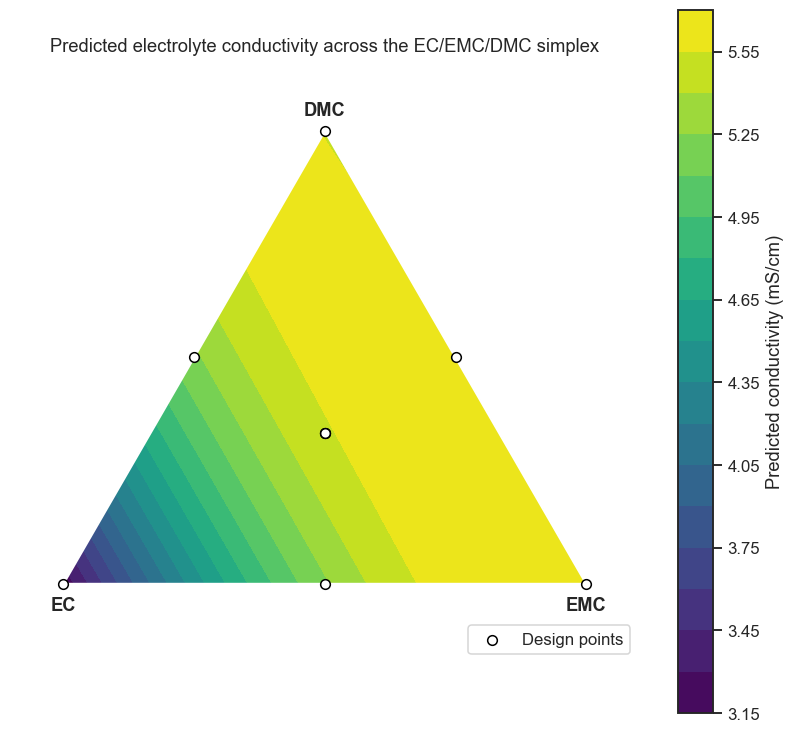

Predicted best blend: EC=0.15, EMC=0.85, DMC=0.00 -> 5.66 mS/cm


In [9]:
def ternary_to_cartesian(x1, x2, x3):
    """EC(x1) at (0,0), EMC(x2) at (1,0), DMC(x3) at (0.5, sqrt(3)/2)."""
    X = x2 + 0.5 * x3
    Y = (np.sqrt(3) / 2) * x3
    return X, Y

# A fine grid covering the whole simplex, for a smooth contour fill
grid_pts = simplex_lattice(q=3, m=40)     # 40 -> 861 points, plenty for a smooth contour
grid_df = pd.DataFrame(grid_pts, columns=['EC', 'EMC', 'DMC'])
grid_df['pred'] = model_mix.predict(grid_df)
gx, gy = ternary_to_cartesian(grid_df.EC, grid_df.EMC, grid_df.DMC)

fig, ax = plt.subplots(figsize=(7.5, 6.8))
contour = ax.tricontourf(gx, gy, grid_df['pred'], levels=20, cmap='viridis')
plt.colorbar(contour, ax=ax, label='Predicted conductivity (mS/cm)')

# Triangle outline and vertex labels
triangle = plt.Polygon([(0, 0), (1, 0), (0.5, np.sqrt(3)/2)], fill=False, edgecolor='white', lw=1.5)
ax.add_patch(triangle)
for label, (vx, vy) in zip(['EC', 'EMC', 'DMC'], [(0, -0.05), (1, -0.05), (0.5, np.sqrt(3)/2 + 0.03)]):
    ax.text(vx, vy, label, ha='center', fontsize=12, fontweight='bold')

# Overlay the actual design points used to fit the model
dx, dy = ternary_to_cartesian(df_mix.EC, df_mix.EMC, df_mix.DMC)
ax.scatter(dx, dy, color='white', edgecolor='black', s=40, zorder=5, label='Design points')

ax.set_xlim(-0.1, 1.1); ax.set_ylim(-0.15, 1.0)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('Predicted electrolyte conductivity across the EC/EMC/DMC simplex')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

best_idx = grid_df['pred'].idxmax()
print(f"Predicted best blend: EC={grid_df.loc[best_idx,'EC']:.2f}, "
      f"EMC={grid_df.loc[best_idx,'EMC']:.2f}, DMC={grid_df.loc[best_idx,'DMC']:.2f} "
      f"-> {grid_df.loc[best_idx,'pred']:.2f} mS/cm")

**Checkpoint**: the model recommends EC 0.15 / EMC 0.85 / DMC 0 at
5.66 mS/cm. Using the *true* coefficients in the `b` dictionary, what is
the true conductivity of pure DMC, and of the recommended blend? Would a
confirmation run at the recommended blend (Notebook 22 §22.5) reveal a
problem? The next cell checks the model's uncertainty, then repeats the
study with the vertices replicated.

In [10]:
# 1) How sure is the model? Prediction and standard error at three candidate blends
cands = pd.DataFrame([[0.15, 0.85, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]],
                     columns=['EC', 'EMC', 'DMC'], index=['fitted best', 'pure EMC', 'pure DMC'])
pred = model_mix.get_prediction(cands).summary_frame()
true_at = [b['EC']*r.EC + b['EMC']*r.EMC + b['DMC']*r.DMC + b['EC:EMC']*r.EC*r.EMC
           + b['EC:DMC']*r.EC*r.DMC + b['EMC:DMC']*r.EMC*r.DMC for r in cands.itertuples()]
print(pd.DataFrame({'predicted': pred['mean'].values, 'std_err': pred['mean_se'].values,
                    'true value': true_at}, index=cands.index).round(3))

# 2) Replicate the three vertices twice more (6 new runs) and refit
extra = pd.DataFrame([[1, 0, 0], [0, 1, 0], [0, 0, 1]] * 2, columns=['EC', 'EMC', 'DMC'], dtype=float)
extra['conductivity_mS_cm'] = (b['EC']*extra.EC + b['EMC']*extra.EMC + b['DMC']*extra.DMC   # vertices: no blending
                               + rng.normal(0, 0.15, len(extra))).round(3)
df_mix2 = pd.concat([df_mix, extra], ignore_index=True)
model_mix2 = smf.ols('conductivity_mS_cm ~ EC + EMC + DMC + EC:EMC + EC:DMC + EMC:DMC - 1', data=df_mix2).fit()
pred2 = model_mix2.predict(grid_df[['EC', 'EMC', 'DMC']])
best2 = grid_df.loc[pred2.idxmax(), ['EC', 'EMC', 'DMC']]
print(f'\nWith the vertices replicated ({len(df_mix2)} runs): best blend EC={best2.EC:.2f}, '
      f'EMC={best2.EMC:.2f}, DMC={best2.DMC:.2f} -> {pred2.max():.2f} mS/cm')

             predicted  std_err  true value
fitted best      5.665    0.166       5.635
pure EMC         5.602    0.213       5.500
pure DMC         5.540    0.213       6.000

With the vertices replicated (15 runs): best blend EC=0.05, EMC=0.00, DMC=0.95 -> 5.83 mS/cm


:::{admonition} Take-home message
:class: tip

- The ternary plot recommends EC 0.15 / EMC 0.85 at 5.66 mS/cm — but the
  **true best blend is pure DMC, at 6.0 mS/cm**. The recommended blend is
  truly worth 5.64: the EC–EMC synergy is real, but it never beats DMC.
- A confirmation run at the recommended blend would *pass*: its true value
  (5.64) is almost exactly the prediction (5.66). A confirmation run
  checks the prediction at the point you chose; it cannot tell you that a
  better point exists elsewhere.
- The cause is the single DMC run that came out 3σ low: the model copied
  it, and the whole DMC corner of the triangle looks worse than it is. The
  model's own standard errors (about 0.2 at each candidate) were as large
  as the differences it was ranking. With just two more runs at each
  vertex, the refitted model moves its best blend to about 95% DMC.
- **A model's optimum is only as good as the runs behind it.** Before
  trusting one, look at the prediction uncertainty, and replicate the
  design points that pin it down — in a mixture design, the vertices.
:::

---
## Exercises

**Core practice**

1. **A 4-component mixture**: Add a fourth solvent, **FEC**, to the
   electrolyte study (assign it plausible pure-component conductivity and
   at least one interaction term). Generate a $\{4,2\}$ simplex-lattice
   design with `simplex_lattice(q=4, m=2)` — how many design points does it
   produce, and how does that compare to a $2^4$ full factorial's 16 runs?

2. **Constrained mixture**: In practice, a real formulation often can't use
   the full simplex — e.g. EC must be present between 20% and 40% (pure EC
   at room temperature is a solid, and pure carbonate-free blends have
   poor Li⁺ solvation). Filter `simplex_lattice(q=3, m=10)` to only the
   points satisfying `0.2 <= EC <= 0.4`, and note how this reshapes the
   feasible region — this smaller shape is what real "constrained mixture
   designs" (D-optimal, beyond this course) are built to cover efficiently.

**Deeper practice**

3. **Special cubic model**: Extend Section 25.4's model formula with a
   three-way mixture term, `EC:EMC:DMC` (the mixture analogue of a 3-factor
   interaction — called the "special cubic" term in mixture-design
   terminology). Refit and check whether it's significant with only 9 design
   points; if the model is now nearly saturated, explain in one sentence
   why a real special-cubic study would need a larger design (hint: how
   many *additional* interior points would a $\{3,3\}$ simplex-lattice
   design provide beyond $\{3,2\}$?).

4. **Optimize under a lower bound**: Using Section 25.5's fitted model,
   search only the portion of `grid_df` satisfying `EC >= 0.15` (representing
   a practical minimum EC needed for adequate low-temperature performance,
   a genuine real electrolyte design trade-off) for the best blend. How
   much conductivity is given up compared to the unconstrained optimum
   found in Section 25.5?

5. **Steepest ascent, followed through**: Using Section 25.1's path,
   simulate a response at each suggested step with the true model
   regenerated in Section 25.1 (extended to keep going indefinitely, e.g.
   flattening out automatically past $x=\pm1$ to represent a real process
   limit), and determine after how many steps the curvature test from
   Notebook 22 (Live Tutorial 1) §22.4 would trigger — i.e., when steepest
   ascent should stop and an RSM study (Notebook 19) should begin.

6. **Your own mixture study**: Pick a materials system with a genuine
   proportion constraint — a glass composition (SiO₂/Na₂O/CaO), a metal
   alloy, a polymer blend, a ceramic slurry — and build a $\{3,2\}$
   simplex-lattice or simplex-centroid design for it, following Sections
   25.3–25.5 end to end with your own plausible pure-component values and at
   least one synergy or antagonism term.